<a href="https://colab.research.google.com/github/Marcos-Souza-git/engenharia-de-prompt-ia/blob/main/Aula08_Automacao_com_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Automação com IA
Nome: Marcos Souza
Data: 17/04/26

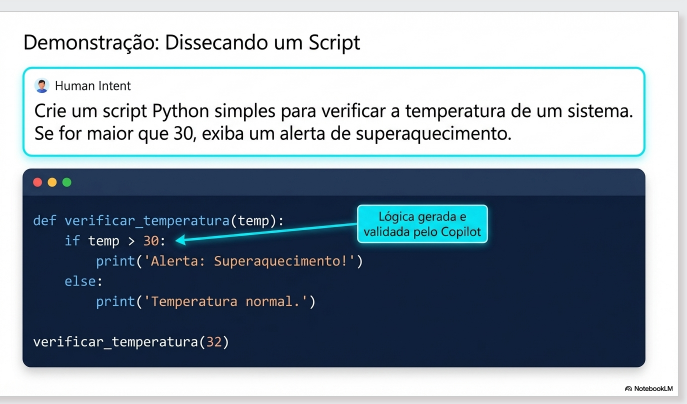

Crie um script Python simples para verificar a temperatura de um sistema.
Se for maior que 30, exiba um alerta de superaquecimento

In [ ]:
# Define o limite de temperatura para alerta de superaquecimento
TEMPERATURA_LIMITE = 30

def verificar_temperatura(temperatura):
  """
  Verifica a temperatura de um sistema e exibe um alerta se estiver acima do limite.

  Args:
    temperatura (int/float): A temperatura atual a ser verificada.
  """
  if temperatura > TEMPERATURA_LIMITE:
    # Exibe um alerta de superaquecimento com a temperatura atual
    print(f'Alerta: Superaquecimento! Temperatura atual: {temperatura}°C')
  else:
    # Exibe uma mensagem de temperatura normal
    print(f'Temperatura Normal. Temperatura atual: {temperatura}°C')

### Exemplo de Uso

In [ ]:
# --- Exemplos de Uso da Função verificar_temperatura ---

# Exemplo 1: Temperatura abaixo do limite (normal)
# A temperatura de 25°C está abaixo do limite de 30°C, então nenhuma ação é necessária.
verificar_temperatura(25)

# Exemplo 2: Temperatura acima do limite (superaquecimento)
# A temperatura de 35°C está acima do limite de 30°C, acionando o alerta.
verificar_temperatura(35)

Temperatura Normal. Temperatura atual: 25°C
Alerta: Superaquecimento! Temperatura atual: 35°C


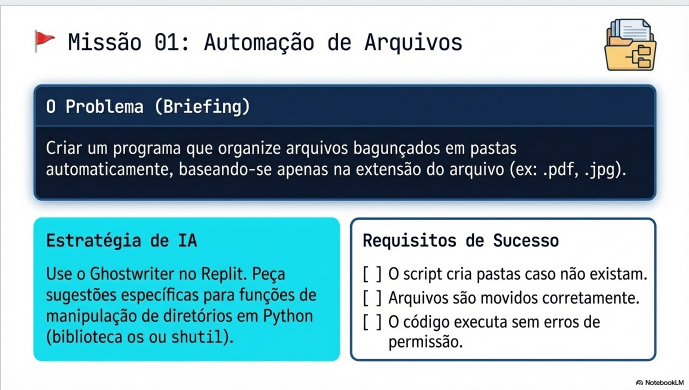

criar um programa que organize arquivos bagunçados em pastas automaticamente, baseando-as apenas na exterção do arquivo (ex:, .pdf,.jpn,.xls,.doc,.py,.ipynb.
use a biblioteca ose shutil, comentea executacao dutante o codigo. use 10 arquivos de cada tipo

### Organizador de Arquivos por Extensão

Este script Python organiza arquivos em subpastas com base em suas extensões. Ele irá percorrer uma pasta de origem, identificar a extensão de cada arquivo e, em seguida, mover o arquivo para uma subpasta correspondente (ex: 'PDF' para arquivos .pdf, 'JPG' para arquivos .jpg) dentro de uma pasta de destino especificada. Se a subpasta não existir, ela será criada.

In [ ]:
import os
import shutil
import random

def organizar_arquivos_por_extensao(caminho_origem, caminho_destino):
  """
  Organiza arquivos de um diretório de origem em subpastas no diretório de destino,
  baseando-se na extensão de cada arquivo.

  Args:
    caminho_origem (str): O caminho para o diretório que contém os arquivos a serem organizados.
    caminho_destino (str): O caminho para o diretório onde as pastas organizadas serão criadas.
  """
  print(f"Iniciando a organização de arquivos de '{caminho_origem}' para '{caminho_destino}'")

  # Verifica se o diretório de origem existe
  if not os.path.exists(caminho_origem):
    print(f"Erro: O diretório de origem '{caminho_origem}' não existe. Por favor, crie-o ou verifique o caminho.")
    return

  # Cria o diretório de destino se ele não existir
  if not os.path.exists(caminho_destino):
    os.makedirs(caminho_destino)
    print(f"Diretório de destino '{caminho_destino}' criado com sucesso.")

  # Itera sobre todos os itens no diretório de origem
  for nome_arquivo in os.listdir(caminho_origem):
    caminho_completo_origem = os.path.join(caminho_origem, nome_arquivo)

    # Verifica se o item é um arquivo (ignora subdiretórios)
    if os.path.isfile(caminho_completo_origem):
      # Obtém a extensão do arquivo (ex: '.pdf', '.jpg')
      _, extensao = os.path.splitext(nome_arquivo)
      extensao = extensao.lower() # Converte para minúsculas para padronização

      if extensao: # Processa apenas arquivos com extensão
        # Remove o ponto e usa a extensão como nome da pasta (ex: 'pdf', 'jpg')
        nome_pasta = extensao[1:].upper() # Ex: .pdf -> PDF, .jpg -> JPG
        caminho_pasta_destino = os.path.join(caminho_destino, nome_pasta)

        # Cria a pasta de destino para a extensão se ela não existir
        if not os.path.exists(caminho_pasta_destino):
          os.makedirs(caminho_pasta_destino)
          print(f"  -> Pasta '{nome_pasta}' criada em '{caminho_destino}'.")

        # Define o caminho completo para o destino do arquivo
        caminho_completo_destino = os.path.join(caminho_pasta_destino, nome_arquivo)
        try:
          # Move o arquivo para a pasta de destino
          shutil.move(caminho_completo_origem, caminho_completo_destino)
          print(f"  -> Movido '{nome_arquivo}' para '{nome_pasta}/'")
        except shutil.Error as e:
          print(f"  -> Erro ao mover '{nome_arquivo}': {e} (possivelmente arquivo já existe ou permissão negada).")
        except Exception as e:
          print(f"  -> Erro inesperado ao mover '{nome_arquivo}': {e}")
      else:
        print(f"  -> Arquivo '{nome_arquivo}' não possui extensão, será ignorado.")
    else:
      print(f"  -> Ignorando diretório: '{nome_arquivo}'")

  print("\nOrganização de arquivos concluída!")

### Demonstração de Uso

Para demonstrar o funcionamento do script, primeiro vamos criar um diretório de origem (`/content/MeusArquivosBaguncados`) e preenchê-lo com 10 arquivos de diferentes extensões cada (PDF, JPG, XLS, DOC, PY, IPYNB, TXT, CSV). Em seguida, executaremos a função `organizar_arquivos_por_extensao` para ver a magia acontecer.

In [ ]:
# Defina o diretório de origem (onde os arquivos bagunçados serão criados)
DIRETORIO_ORIGEM = '/content/MeusArquivosBaguncados'

# Defina o diretório de destino (onde as pastas organizadas serão criadas)
DIRETORIO_DESTINO = '/content/ArquivosOrganizados'

# Lista de extensões e seus conteúdos de exemplo
EXTENSOES = {
    '.pdf': 'Conteúdo de um arquivo PDF simulado.',
    '.jpg': 'Bytes de imagem JPG simulados.',
    '.xls': 'Dados de planilha XLS simulados.',
    '.doc': 'Texto de documento DOC simulado.',
    '.py': 'print("Este é um script Python.")',
    '.ipynb': '{\"cells\": [], \"metadata\": {}, \"nbformat\": 4, \"nbformat_minor\": 5}', # Conteúdo básico de um notebook
    '.txt': 'Isto é um arquivo de texto simples.',
    '.csv': 'nome,idade\nJoao,30\nMaria,25'
}

NUM_ARQUIVOS_POR_TIPO = 10

# --- Configuração: Criação de arquivos de teste ---
print(f"Preparando o diretório de origem: '{DIRETORIO_ORIGEM}'")
# Limpa o diretório de origem se ele já existir
if os.path.exists(DIRETORIO_ORIGEM):
    shutil.rmtree(DIRETORIO_ORIGEM)
os.makedirs(DIRETORIO_ORIGEM)
print("Diretório de origem criado/limpo.")

# Cria 10 arquivos para cada tipo de extensão especificado
for ext, content in EXTENSOES.items():
    for i in range(1, NUM_ARQUIVOS_POR_TIPO + 1):
        nome_arquivo = f'arquivo_teste_{random.randint(1000, 9999)}{ext}'
        caminho_arquivo = os.path.join(DIRETORIO_ORIGEM, nome_arquivo)
        with open(caminho_arquivo, 'w') as f:
            f.write(content)
        # print(f"  -> Criado: {nome_arquivo}") # Descomente para ver cada arquivo sendo criado

# Adiciona alguns arquivos sem extensão para teste
for i in range(1, 3):
    nome_arquivo_sem_ext = f'arquivo_sem_extensao_{i}'
    caminho_arquivo_sem_ext = os.path.join(DIRETORIO_ORIGEM, nome_arquivo_sem_ext)
    with open(caminho_arquivo_sem_ext, 'w') as f:
        f.write('Conteúdo sem extensão')
    # print(f"  -> Criado: {nome_arquivo_sem_ext}") # Descomente para ver cada arquivo sendo criado

print(f"Total de {len(EXTENSOES) * NUM_ARQUIVOS_POR_TIPO + 2} arquivos de teste criados em '{DIRETORIO_ORIGEM}'.\n")

# --- Executa a função para organizar os arquivos ---
organizar_arquivos_por_extensao(DIRETORIO_ORIGEM, DIRETORIO_DESTINO)

print("\nVerifique o conteúdo de '/content/ArquivosOrganizados' para ver os arquivos organizados.")

Preparando o diretório de origem: '/content/MeusArquivosBaguncados'
Diretório de origem criado/limpo.
Total de 82 arquivos de teste criados em '/content/MeusArquivosBaguncados'.

Iniciando a organização de arquivos de '/content/MeusArquivosBaguncados' para '/content/ArquivosOrganizados'
Diretório de destino '/content/ArquivosOrganizados' criado com sucesso.
  -> Pasta 'IPYNB' criada em '/content/ArquivosOrganizados'.
  -> Movido 'arquivo_teste_7481.ipynb' para 'IPYNB/'
  -> Pasta 'PY' criada em '/content/ArquivosOrganizados'.
  -> Movido 'arquivo_teste_2143.py' para 'PY/'
  -> Pasta 'DOC' criada em '/content/ArquivosOrganizados'.
  -> Movido 'arquivo_teste_5167.doc' para 'DOC/'
  -> Pasta 'PDF' criada em '/content/ArquivosOrganizados'.
  -> Movido 'arquivo_teste_1418.pdf' para 'PDF/'
  -> Pasta 'CSV' criada em '/content/ArquivosOrganizados'.
  -> Movido 'arquivo_teste_9666.csv' para 'CSV/'
  -> Movido 'arquivo_teste_5279.doc' para 'DOC/'
  -> Movido 'arquivo_teste_1553.csv' para 'CSV/'